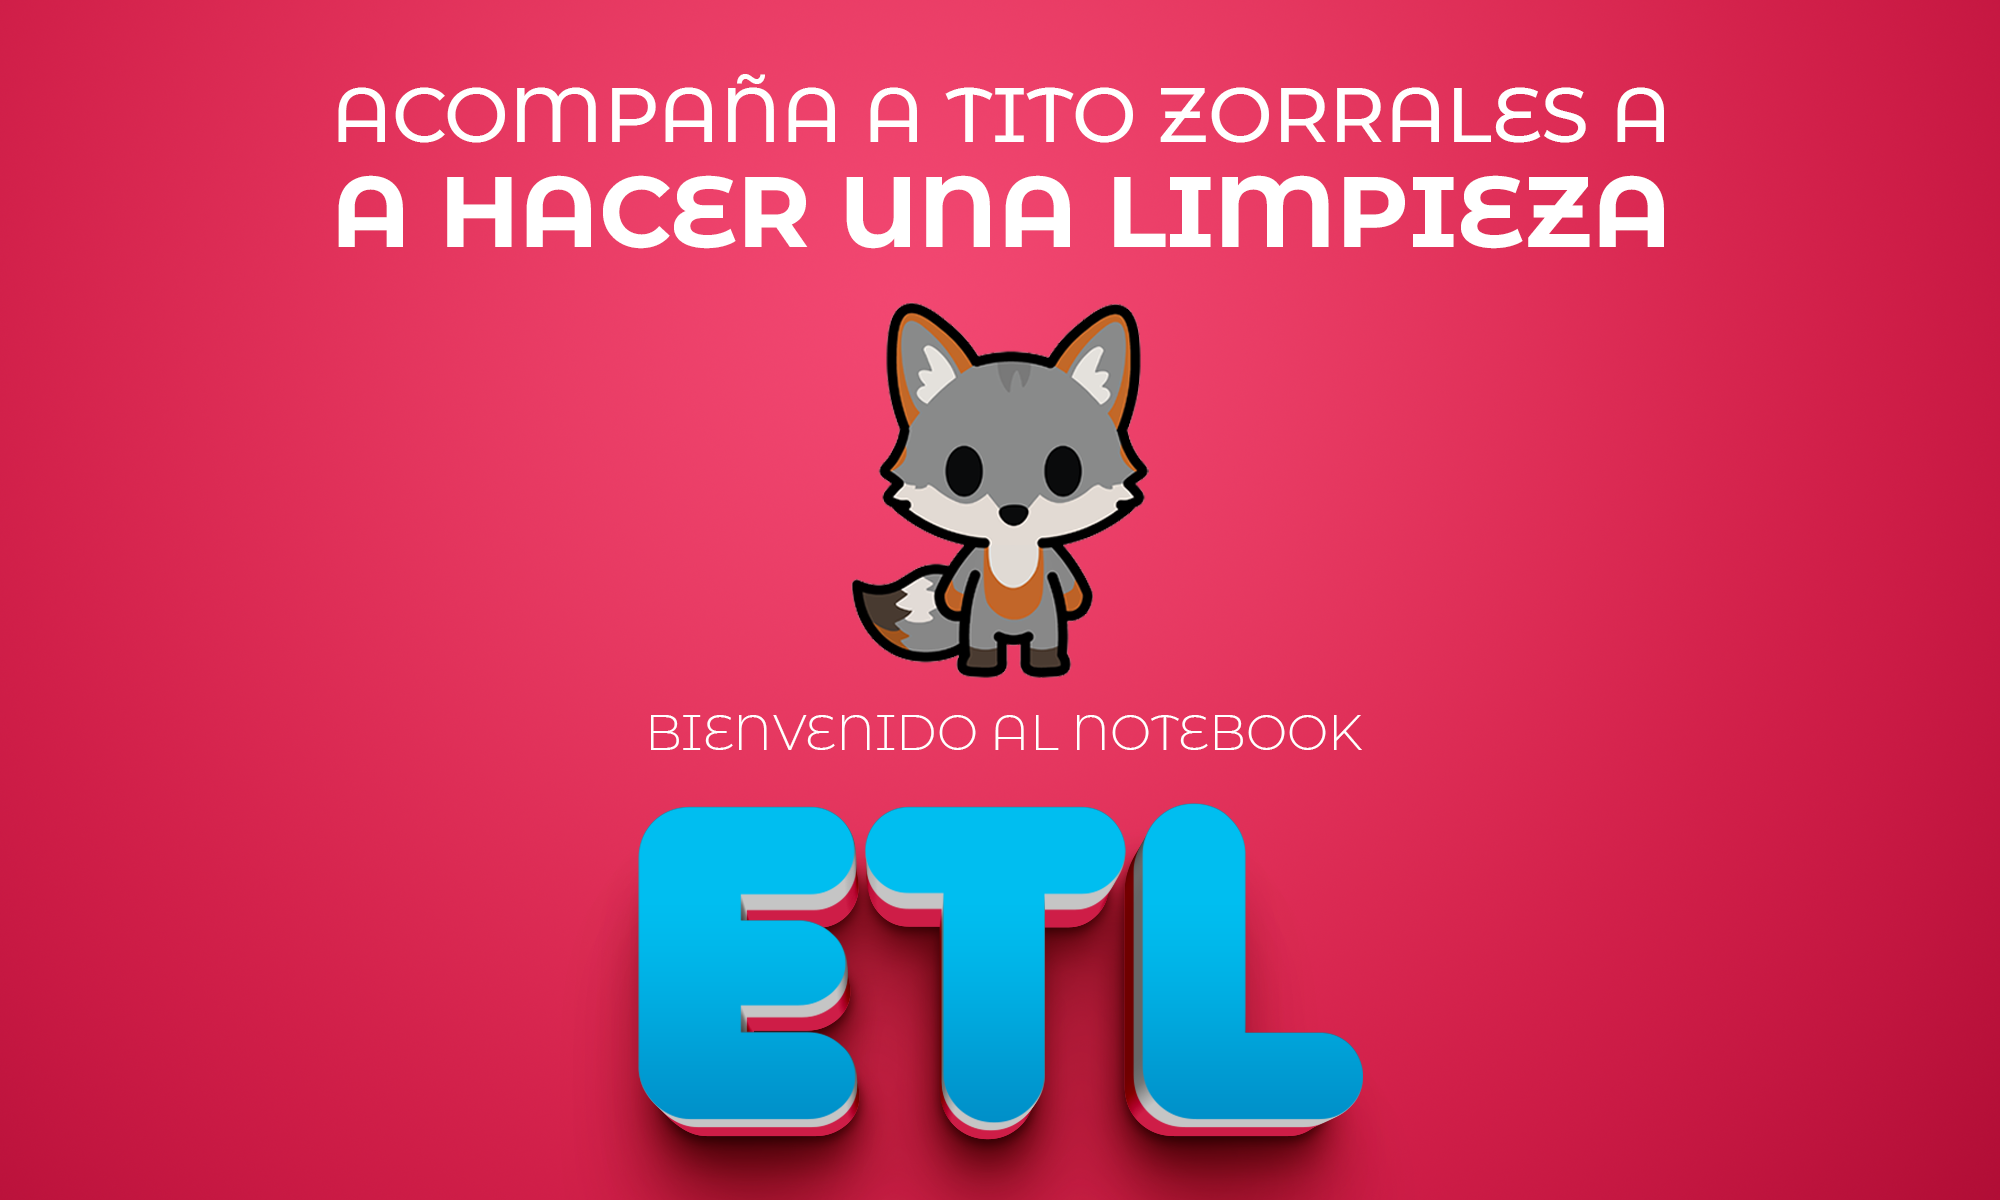

In [1]:
from IPython.display import Image
Image(r"C:\Users\Lilir\Desktop\PortadaETL.png")

<div style="background-color:#F4F5F7; padding:34px 42px; border-radius:8px; border:1px solid #E1E4E8; margin-bottom:18px;">
<p style="color:#6B7280; font-size:12px; font-weight:600; letter-spacing:2px; text-transform:uppercase; margin:0 0 10px 0;">Proceso ETL</p>
<h1 style="color:#2C2C2C; margin:0; font-size:30px; font-weight:700;">PimPamBoing — VividChroma Games</h1>
<p style="color:#5A5A5A; font-size:14.5px; margin:10px 0 0 0;">Extracción, Transformación y Carga de datos de ventas — estado de Puebla</p>
</div>


<div style="background-color:#FAFAFA; padding:22px 30px; border-radius:6px; border-left:4px solid #5B7C99; margin-bottom:18px;">
<h3 style="color:#2C2C2C; margin-top:0; font-size:15.5px;">Contexto</h3>
<p style="color:#4A4A4A; font-size:14px; line-height:1.7; text-align:justify; margin:0;">
Antes de que PimPamBoing pueda extraer valor estratégico de su tienda virtual de mercancía física, los datos deben pasar por un proceso de ingeniería. Las fuentes transaccionales crudas (ventas, jugadores, productos, ubicaciones) contienen inconsistencias reales: registros duplicados, cantidades inválidas y variaciones de formato en texto. Este notebook construye el pipeline de <b>Extracción, Transformación y Carga (ETL)</b> que resuelve esos problemas y entrega un dataset maestro confiable para el notebook de EDA.
</p>
</div>

<div style="background-color:#FAFAFA; padding:22px 30px; border-radius:6px; border-left:4px solid #7C9885; margin-bottom:18px;">
<h3 style="color:#2C2C2C; margin-top:0; font-size:15.5px;">Objetivos del proceso ETL</h3>
<ol style="color:#4A4A4A; font-size:14px; line-height:1.9; margin:0; padding-left:20px;">
<li>Extraer e integrar las 4 fuentes relacionales: ventas, jugadores, productos y ubicaciones.</li>
<li>Detectar y eliminar duplicados y transacciones con cantidades inválidas.</li>
<li>Normalizar texto en los catálogos y verificar la integridad referencial entre tablas.</li>
<li>Calcular las métricas financieras (Ingreso Total, Costo Total, Utilidad) por transacción.</li>
<li>Definir y calcular los KPI de negocio, con metas, alertas y semáforos.</li>
<li>Exportar el dataset maestro y los catálogos limpios a CSV para el EDA.</li>
</ol>
</div>
<div style="background-color:#FAFAFA; padding:20px 30px; border-radius:6px; border:1px solid #E1E4E8; margin-bottom:18px;">
<table style="width:100%; border-collapse:collapse;">
<tr><td style="padding:8px 14px; color:#8A8A8A; font-size:12.5px; font-weight:600; width:200px;">PROGRAMA</td><td style="padding:8px 14px; color:#2C2C2C; font-size:13.5px;">Ingeniería en Entornos Virtuales y Negocios Digitales</td></tr>
<tr><td style="padding:8px 14px; color:#8A8A8A; font-size:12.5px; font-weight:600;">ASIGNATURA</td><td style="padding:8px 14px; color:#2C2C2C; font-size:13.5px;">Analítica de Datos para Negocios Digitales</td></tr>
<tr><td style="padding:8px 14px; color:#8A8A8A; font-size:12.5px; font-weight:600;">DOCENTE</td><td style="padding:8px 14px; color:#2C2C2C; font-size:13.5px;">M.T.I. Marco A. Ramírez Hernández</td></tr>
<tr><td style="padding:8px 14px; color:#8A8A8A; font-size:12.5px; font-weight:600;">PERIODO</td><td style="padding:8px 14px; color:#2C2C2C; font-size:13.5px;">Mayo - Agosto 2026</td></tr>
<tr><td style="padding:8px 14px; color:#8A8A8A; font-size:12.5px; font-weight:600; vertical-align:top;">INTEGRANTES</td><td style="padding:8px 14px; color:#2C2C2C; font-size:13.5px; line-height:1.8;">
Liliana Rosales Gómez · Samantha Salazar Fernández · Ilse Guadalupe Saavedra Villa · Adriana Rosales Gayoso · Angélica Citlali Gutiérrez Ortega
</td></tr>
</table>
</div>



<div style="background-color:#EEF2F5; border-left:4px solid #5B7C99; padding:20px 28px; border-radius:6px; margin:28px 0 18px 0;">
<p style="color:#5B7C99; font-size:12px; font-weight:600; letter-spacing:1.5px; text-transform:uppercase; margin:0 0 6px 0;">Etapa 4</p>
<h2 style="color:#2C2C2C; margin:0 0 6px 0; font-size:21px; font-weight:600;">Calidad de Datos y Proceso ETL</h2>
<p style="color:#5A5A5A; font-size:13.5px; line-height:1.6; margin:0;">Extracción de las fuentes primarias de la tienda de PimPamBoing, limpieza de anomalías controladas (nulos, duplicados, rangos inválidos) y cálculo de los campos financieros necesarios para el EDA.</p>
</div>

<div style="border-bottom:2px solid #5B7C99; padding-bottom:6px; margin:20px 0 10px 0;">
<h3 style="color:#2C2C2C; margin:0; font-size:15.5px; font-weight:600;">4.1 Inicialización de Entorno y Carga de Datos Crudos</h3>
</div>

Se ingestan las 4 fuentes reales del proyecto (`jugadores`, `productos`, `ubicaciones`, `ventas_sucias`) con `pd.read_csv()` — los archivos vienen con extensión `.xls` pero su contenido real es CSV. Enseguida se corre un perfilado con `isnull()` y `duplicated()` para auditar cuánta inconsistencia trae `ventas_sucias` antes de tocarla.

In [7]:
import pandas as pd
import numpy as np
import glob
import os

np.random.seed(2026)

CARPETA_DATOS = '../data'

def cargar_fuente(nombre_base):
    """
    Busca el archivo de una fuente (jugadores, productos, ubicaciones,
    ventas_sucias) dentro de CARPETA_DATOS, sin importar si termina en
    .csv o .xls, ni si trae sufijos (p.ej. 'jugadores__1_.xls').
    """
    patrones = [f"{nombre_base}*.csv", f"{nombre_base}*.xls", f"{nombre_base}*.xlsx"]
    coincidencias = []
    for patron in patrones:
        coincidencias.extend(glob.glob(os.path.join(CARPETA_DATOS, patron)))
    if not coincidencias:
        raise FileNotFoundError(
            f"No encontré ningún archivo que empiece con '{nombre_base}' en: "
            f"{os.path.abspath(CARPETA_DATOS)}\n"
            f"Archivos disponibles ahí: {os.listdir(CARPETA_DATOS) if os.path.isdir(CARPETA_DATOS) else 'la carpeta no existe'}\n"
            f"Revisa que CARPETA_DATOS apunte bien a tu carpeta 'data'."
        )
    archivo = coincidencias[0]
    
    return pd.read_csv(archivo)

jugadores   = cargar_fuente('jugadores')
productos   = cargar_fuente('productos')
ubicaciones = cargar_fuente('ubicaciones')
ventas      = cargar_fuente('ventas_sucias')

print("--- REPORTE AUDITORÍA DE CALIDAD INICIAL (ventas_sucias) ---")
print(f"Registros totales: {ventas.shape[0]}")
print(f"Nulos por columna:\n{ventas.isnull().sum()}")
print(f"Ventas con cantidad <= 0 o nula: {((ventas['cantidad'] <= 0) | (ventas['cantidad'].isnull())).sum()}")
print(f"Duplicados exactos (mismo renglón repetido): "
      f"{ventas.duplicated(subset=['venta_id','fecha_venta','jugador_id','producto_id','ubicacion_id','cantidad']).sum()}")

--- REPORTE AUDITORÍA DE CALIDAD INICIAL (ventas_sucias) ---
Registros totales: 3379
Nulos por columna:
id_renglon       0
venta_id         0
fecha_venta      0
jugador_id       0
producto_id      0
ubicacion_id     0
cantidad        34
dtype: int64
Ventas con cantidad <= 0 o nula: 68
Duplicados exactos (mismo renglón repetido): 116


<div style="border-bottom:2px solid #7C9885; padding-bottom:6px; margin:20px 0 10px 0;">
<h3 style="color:#2C2C2C; margin:0; font-size:15.5px; font-weight:600;">4.2 Algoritmos de Transformación y Depuración</h3>
</div>

Reglas de negocio aplicadas sobre `ventas_sucias` y los catálogos:

- **`drop_duplicates(subset=...)`** — remueve renglones idénticos repetidos (mismo evento capturado dos veces con distinto `id_renglon`), para evitar sobreestimar los ingresos.
- **Filtro de cantidad nula/cero** — descarta ventas sin una cantidad válida; no se imputa porque no hay forma confiable de estimarla sin distorsionar los KPIs financieros.
- **`str.title()` / `str.strip()`** — normaliza texto en los catálogos (municipio, estado, categoría) para que no queden duplicidades ocultas por mayúsculas o espacios al agrupar.
- **Verificación de integridad referencial** — confirma que cada `producto_id`, `jugador_id` y `ubicacion_id` de las ventas exista en su catálogo, antes de cruzar las tablas.

In [9]:

ventas_clean = ventas.drop_duplicates(
    subset=['venta_id', 'fecha_venta', 'jugador_id', 'producto_id', 'ubicacion_id', 'cantidad']
).copy()


ventas_clean = ventas_clean[ventas_clean['cantidad'].notnull()]
ventas_clean = ventas_clean[ventas_clean['cantidad'] > 0]
ventas_clean['cantidad'] = ventas_clean['cantidad'].astype(int)

ventas_clean['fecha_venta'] = pd.to_datetime(ventas_clean['fecha_venta'])


huerfanos_prod = set(ventas_clean['producto_id']) - set(productos['producto_id'])
huerfanos_jug  = set(ventas_clean['jugador_id']) - set(jugadores['jugador_id'])
huerfanos_ubi  = set(ventas_clean['ubicacion_id']) - set(ubicaciones['ubicacion_id'])
print(f"Producto_id sin catálogo: {huerfanos_prod}")
print(f"Jugador_id sin catálogo: {len(huerfanos_jug)}")
print(f"Ubicacion_id sin catálogo: {len(huerfanos_ubi)}")


jugadores_clean = jugadores.drop_duplicates().copy()
jugadores_clean['fecha_registro'] = pd.to_datetime(jugadores_clean['fecha_registro'])

productos_clean = productos.drop_duplicates().copy()
productos_clean['categoria'] = productos_clean['categoria'].str.strip().str.title()
productos_clean['nombre'] = productos_clean['nombre'].str.strip()

ubicaciones_clean = ubicaciones.drop_duplicates().copy()
ubicaciones_clean['municipio'] = ubicaciones_clean['municipio'].str.strip().str.title()
ubicaciones_clean['estado'] = ubicaciones_clean['estado'].str.strip().str.title()

print(f"\nDimensiones finales post-limpieza (ventas): {ventas_clean.shape} (eran {ventas.shape})")

Producto_id sin catálogo: set()
Jugador_id sin catálogo: 0
Ubicacion_id sin catálogo: 0

Dimensiones finales post-limpieza (ventas): (3195, 7) (eran (3379, 7))


In [10]:
correcciones_nombre = {
    'Botella de Agua TDAH': 'Botella de Agua',
    'Cómic Oficial Vol 1 (Físico)': 'Cómic Físico',
    'Cómic Oficial Vol 1 (Virtual)': 'Cómic Virtual',
}
productos_clean['nombre'] = productos_clean['nombre'].replace(correcciones_nombre)

<div style="border-bottom:2px solid #B08968; padding-bottom:6px; margin:20px 0 10px 0;">
<h3 style="color:#2C2C2C; margin:0; font-size:15.5px; font-weight:600;">4.3 Enriquecimiento de Variables Financieras</h3>
</div>

Se une `ventas_clean` con los tres catálogos depurados (productos, jugadores, ubicaciones) y se calculan los KPIs de negocio requeridos:

- **`Ingreso_Total`** — flujo bruto de caja: piezas vendidas × precio de venta.
- **`Costo_Total`** — egreso operativo: piezas vendidas × costo de fabricación.
- **`Utilidad`** — diferencia neta entre ingreso y costo; el indicador crítico para la toma de decisiones del dueño.

In [11]:

df_clean = (
    ventas_clean
    .merge(productos_clean,   on='producto_id',   how='left')
    .merge(jugadores_clean,   on='jugador_id',     how='left')
    .merge(ubicaciones_clean, on='ubicacion_id',   how='left')
)


df_clean['Ingreso_Total'] = df_clean['cantidad'] * df_clean['precio']
df_clean['Costo_Total']   = df_clean['cantidad'] * df_clean['costo']
df_clean['Utilidad']      = df_clean['Ingreso_Total'] - df_clean['Costo_Total']

print(f"Dimensiones dataset maestro: {df_clean.shape}")


df_clean.head()

Dimensiones dataset maestro: (3195, 21)


,id_renglon,venta_id,fecha_venta,jugador_id,producto_id,ubicacion_id,cantidad,nombre,categoria,precio,...,fecha_registro,edad_nino,tipo_suscripcion,estado,municipio,latitud,longitud,Ingreso_Total,Costo_Total,Utilidad
0,1,50001,2024-03-18,JUG-206,PROD-01,UBI-PUE288,1,Cómic Físico,Lectura,150.0,...,2024-01-07,11,Gratuita,Puebla,Heroica Puebla De Zaragoza,19.121479,-98.222522,150.0,45.0,105.0
1,2,50001,2024-03-18,JUG-206,PROD-08,UBI-PUE288,2,Planilla Stickers,Papelería,35.0,...,2024-01-07,11,Gratuita,Puebla,Heroica Puebla De Zaragoza,19.121479,-98.222522,70.0,16.0,54.0
2,3,50002,2024-01-29,JUG-034,PROD-07,UBI-PUE042,1,Libreta de Tareas,Papelería,110.0,...,2023-01-23,10,Gratuita,Puebla,Tehuacán,18.448646,-97.410885,110.0,30.0,80.0
3,4,50002,2024-01-29,JUG-034,PROD-08,UBI-PUE042,1,Planilla Stickers,Papelería,35.0,...,2023-01-23,10,Gratuita,Puebla,Tehuacán,18.448646,-97.410885,35.0,8.0,27.0
4,5,50002,2024-01-29,JUG-034,PROD-03,UBI-PUE042,1,Peluche Personaje Coleccionable,Peluches,280.0,...,2023-01-23,10,Gratuita,Puebla,Tehuacán,18.448646,-97.410885,280.0,90.0,190.0


<div style="border-bottom:2px solid #5C6B73; padding-bottom:6px; margin:20px 0 10px 0;">
<h3 style="color:#2C2C2C; margin:0; font-size:15.5px; font-weight:600;">4.4 Almacenamiento y Carga (Load) del Dataset Maestro</h3>
</div>

La fase final exporta el dataset maestro y los catálogos depurados a CSV persistentes, listos para ser leídos por el notebook de EDA sin volver a tocar los datos crudos — con `to_csv()`.

In [12]:

df_df = df_clean.copy()

df_df.to_csv('dataset_maestro_vividchroma.csv', index=False)
jugadores_clean.to_csv('jugadores_limpio.csv', index=False)
productos_clean.to_csv('productos_limpio.csv', index=False)
ubicaciones_clean.to_csv('ubicaciones_limpio.csv', index=False)
ventas_clean.to_csv('ventas_limpio.csv', index=False)

print("¡Proceso ETL concluido de forma exitosa!")
print(f"Los datos han sido extraídos, limpiados de anomalías y exportados a CSV.")
print(f"Dataset maestro: {df_df.shape[0]} filas x {df_df.shape[1]} columnas.")

¡Proceso ETL concluido de forma exitosa!
Los datos han sido extraídos, limpiados de anomalías y exportados a CSV.
Dataset maestro: 3195 filas x 21 columnas.


<div style="background-color:#F3F4F6; border-left:4px solid #6B7280; padding:20px 28px; border-radius:6px; margin:28px 0 18px 0;">
<p style="color:#6B7280; font-size:12px; font-weight:600; letter-spacing:1.5px; text-transform:uppercase; margin:0 0 6px 0;">Conclusión</p>
<h2 style="color:#2C2C2C; margin:0; font-size:21px; font-weight:600;">¿Por qué este ETL salva nuestra App de Compras?</h2>
</div>

<div style="background-color:#F9FAFB; padding:24px 30px; border-radius:6px; border:1px solid #E1E4E8;">
<p style="color:#3A3A3A; font-size:14px; line-height:1.8; text-align:justify; margin-bottom:14px;">La verdad es que al principio los datos parecían un desastre: <code>ventas_sucias</code> traía 116 renglones duplicados exactos y 34 ventas sin una cantidad de piezas válida (nula o en cero). Si hubiéramos metido los datos así de sucios directo a las gráficas o a los mapas de calor, el análisis habría salido completamente mal. Por ejemplo, la app registraría ganancias infladas (por culpa de los duplicados) o subestimaría el volumen real de piezas vendidas (por los renglones sin cantidad).</p>
<p style="color:#3A3A3A; font-size:14px; line-height:1.8; margin-bottom:10px;">Hacer esta depuración es clave para la app de compras por tres razones muy sencillas:</p>
<ul style="color:#3A3A3A; font-size:14px; line-height:1.8; margin:0 0 14px 0; padding-left:20px;">
<li style="margin-bottom:8px;"><b>No tomamos decisiones con mentiras:</b> al borrar las ventas duplicadas y los renglones sin cantidad válida, sabemos exactamente cuántos productos reales se vendieron y cuánto dinero entró a la caja sin inflar los números.</li>
<li style="margin-bottom:8px;"><b>Ubicamos al cliente real:</b> al cruzar la tabla de Ubicaciones con las Ventas (verificando que cada ubicacion_id exista en el catálogo), ahora sí podemos identificar qué municipios de Puebla consumen más, para mandar el inventario correcto allá.</li>
<li style="margin-bottom:8px;"><b>Sabemos qué negocio es rentable:</b> al automatizar las fórmulas de Ingreso, Costo y Utilidad cruzando los datos reales de la tabla de Productos, el dueño de la app puede ver con un solo clic qué categorías sí están dejando dinero limpio y cuáles no.</li>
</ul>
<p style="color:#3A3A3A; font-size:14px; line-height:1.8; text-align:justify; margin:0;">En conclusión, el ETL fue como el filtro que limpió el agua sucia. Ahora que el dataset maestro <code>df_df</code> está impecable, bien relacionado y exportado a CSV, estamos listos para hacer el Análisis Exploratorio (EDA) en un notebook aparte, con la total seguridad de que los resultados son 100% reales y confiables.</p>
</div>

<div style="background-color:#F3F4F6; border-left:4px solid #6B7280; padding:20px 28px; border-radius:6px; margin:28px 0 18px 0;">
<p style="color:#6B7280; font-size:12px; font-weight:600; letter-spacing:1.5px; text-transform:uppercase; margin:0 0 6px 0;"></p>
<h2 style="color:#2C2C2C; margin:0; font-size:21px; font-weight:600;">LISTOS PARA EL DESARROLLO DE NOTEBOOK EDA!</h2>
</div>